# HF2 锁相放大器控制示例

本示例演示如何使用 `lockin_amplifier` 包控制 Zurich Instruments HF2 锁相放大器。

## 前提条件
- HF2 设备已通过 USB 或以太网连接
- LabOne 数据服务器 (ziServer.exe) 已在 PC 上运行
- 虚拟环境 `agent_exp_env` 已配置好依赖
- 在 VSCode 中打开此 notebook 后右上角选择内核 `Python (agent_exp_env)`

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import logging
# logging.basicConfig(level=logging.DEBUG)
# 将项目根目录添加到 sys.path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from lockin_amplifier import (
    HF2Instrument,
    DemodulatorConfig,
    DAQConfig,
    AuxOutConfig,
    demod,
    daq,
    auxout,
    SignalInputConfig,
    OscillatorConfig,
    SignalOutputConfig,
)
print("模块导入成功")


模块导入成功


---
## 1. 设备配置

设置连接参数：HF2 的数据服务器默认在 localhost:8005，API Level 为 1。

> **注意**: 根据你的设备修改 device_id（例如 dev2006、dev2007 等）

In [2]:
# ========== 请根据实际设备修改以下参数 ==========
HOST = '127.0.0.1'
PORT = 8005          # HF2 数据服务器端口
API_LEVEL = 1        # HF2 仅支持 API Level 1
DEVICE_ID = "dev18246"
# =============================================

print(f"目标设备: {DEVICE_ID} @ {HOST}:{PORT} (API Level {API_LEVEL})")


目标设备: dev18246 @ 127.0.0.1:8005 (API Level 1)


---
## 2. 连接仪器

使用上下文管理器自动处理连接和断开。

In [3]:
try:
    instr = HF2Instrument(HOST, PORT, API_LEVEL, DEVICE_ID)
    instr.connect()
    print(f"已连接: {instr.idn}")
    print(f"Clockbase: {instr.clockbase} Hz")
except Exception as e:
    print(f"连接失败: {e}")
    print("请确认 LabOne 数据服务器正在运行且设备已连接。")


已连接: HF2LI
Clockbase: 210000000 Hz


---
## 3. 配置解调器 (Demodulator)

设置参考频率、数据速率、时间常数（决定带宽）、滤波器阶数、输入量程和耦合方式。

In [4]:
if instr.connected:
    # 信号输入配置
    input_cfg = SignalInputConfig(
        input_index=0, range=1.0,
        ac_coupling=True, impedance=50,
    )
    demod.configure_signal_input(instr, input_cfg)

    # 振荡器配置
    osc_cfg = OscillatorConfig(
        osc_index=0, frequency=90e3, source="manual",
    )
    demod.configure_oscillator(instr, osc_cfg)

    # 解调器配置（纯解调器参数）
    demod_cfg = DemodulatorConfig(
        demod_index=0, enable=True, rate=20e3,
        input_channel=0, osc_select=0,
        harmonic=1, time_constant=0.001,
        order=4, phase=0.0,
    )
    actual_rate = demod.configure_demodulator(instr, demod_cfg)

    # 信号输出配置
    output_cfg = SignalOutputConfig(
        output_index=0, range=1.0,
        offset=0.0, enable=True, add=False,
    )
    demod.configure_signal_output(instr, output_cfg)

    print("各模块配置完成")
else:
    print("仪器未连接，跳过配置")


各模块配置完成


---
## 4. 相位校准 (Auto Phase)

自动调整参考相位使解调器的 Y 分量 ≈ 0，即输出相位为 0。

In [5]:
if instr.connected:
    sample_before = demod.read_demod_sample(instr, demod_idx=0)
    print(f"校准前: X={sample_before['x']:.6f} V, Y={sample_before['y']:.6f} V, "
          f"R={sample_before['r']:.6f} V, theta={sample_before['theta']:.6f} rad")

    try:
        calibrated_phase = demod.auto_calibrate_phase(
            instr, demod_idx=0, tolerance_deg=0.05, settle_time=0.2,max_attempts=1
        )
        print(f"\n相位校准完成: 补偿相位 = {calibrated_phase:.6f} rad")
    except RuntimeError as e:
        print(f"相位校准失败: {e}")
        print("可能原因: 输入信号幅度过小或无输入信号")

    sample_after = demod.read_demod_sample(instr, demod_idx=0)
    print(f"校准后: X={sample_after['x']:.6f} V, Y={sample_after['y']:.6f} V, "
          f"R={sample_after['r']:.6f} V, theta={sample_after['theta']:.6f} rad")
else:
    print("仪器未连接，跳过相位校准")


校准前: X=0.021949 V, Y=-0.018665 V, R=0.028812 V, theta=-0.704722 rad
相位校准失败: 相位校准失败 (max_attempts=1)，最终 theta=-40.4139 deg
可能原因: 输入信号幅度过小或无输入信号
校准后: X=0.028640 V, Y=-0.000020 V, R=0.028640 V, theta=-0.000704 rad


---
## 5. DAQ 数据采集

使用 Data Acquisition 模块采集解调器输出的 X, Y, R, phase 等信号。
可以设置采集时长、网格点数等参数。

In [6]:
if instr.connected:
    daq_cfg = DAQConfig(
        device=DEVICE_ID,
        trigger_type=0,
        duration=0.1,
        grid_cols=1000,
        grid_rows=1,
        grid_mode=2,
        signal_paths=["sample.r", "sample.x", "sample.y", "sample.theta"],
    )

    try:
        results = daq.acquire_data(instr, daq_cfg, demod_idx=0,
                                   actual_rate=actual_rate)

        print("采集完成! 共 %d 路信号:" % len(results))
        for r in results:
            print("  %s: %d 点, time: %.3f ~ %.3f s" % (
                r.signal_name, len(r.values),
                r.time[0], r.time[-1]))

    except Exception as e:
        print("采集失败: %s" % e)
else:
    print("仪器未连接，跳过 DAQ 采集")


采集完成! 共 4 路信号:
  sample.r: 1000 点, time: 0.000 ~ 0.069 s
  sample.theta: 1000 点, time: 0.000 ~ 0.069 s
  sample.x: 1000 点, time: 0.000 ~ 0.069 s
  sample.y: 1000 点, time: 0.000 ~ 0.069 s


### 5.1 绘制采集数据

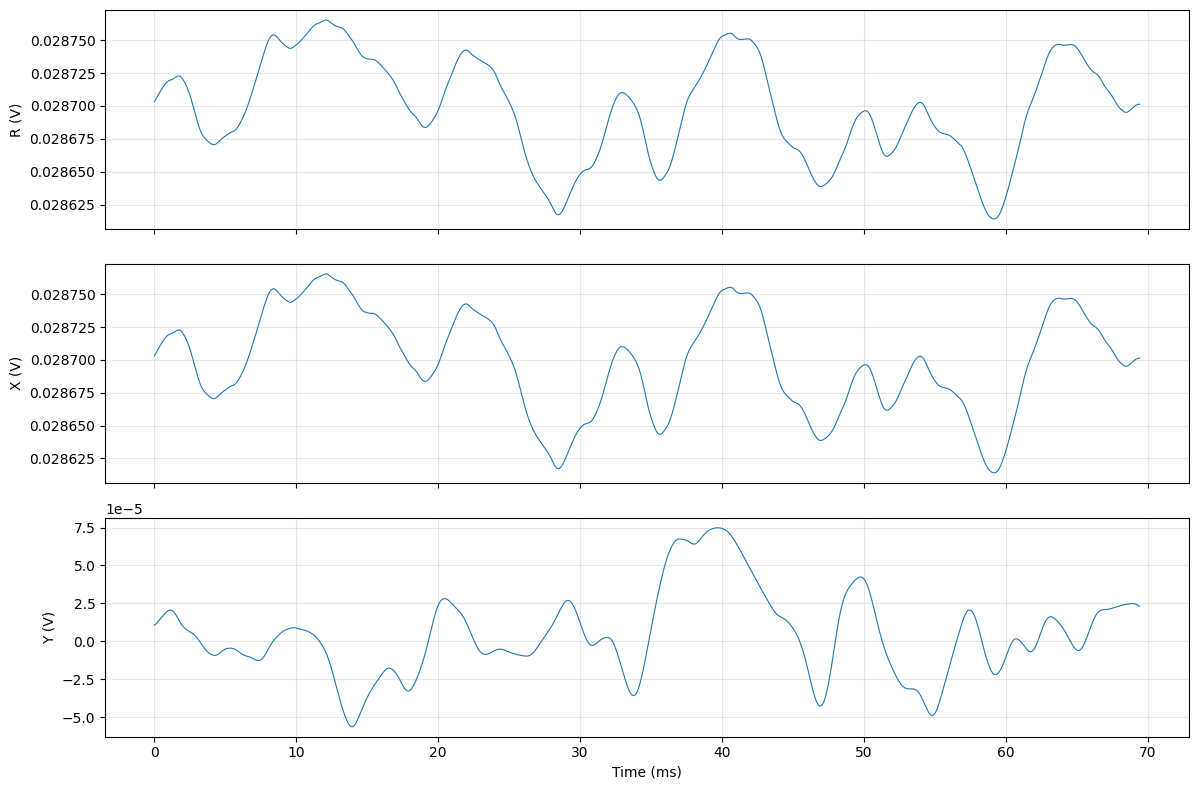

In [7]:
if instr.connected and "results" in dir() and results:
    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

    plot_keys = {"r": "R (V)", "x": "X (V)", "y": "Y (V)"}
    for idx, (key, ylabel) in enumerate(plot_keys.items()):
        for r in results:
            if r.signal_name == "sample." + key:
                t_ms = r.time * 1e3
                axes[idx].plot(t_ms, r.values, lw=0.8)
                axes[idx].set_ylabel(ylabel)
                axes[idx].grid(True, alpha=0.3)
                break

    axes[-1].set_xlabel("Time (ms)")
    plt.tight_layout()
    plt.show()
else:
    print("没有可绘制的数据")


### 5.2 保存采集数据


In [7]:
if instr.connected and "results" in dir() and results:
    import datetime
    from pathlib import Path

    save_dir = project_root / "data"
    save_dir.mkdir(exist_ok=True)
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

    # 保存为 NPZ (每个信号独立文件，与示波器格式保持一致)
    for r in results:
        filename = f"lockin_d{demod_cfg.demod_index}_{r.signal_name}_{timestamp}.npz"
        filepath = save_dir / filename
        np.savez(filepath,
                 values=r.values,
                 time=r.time,
                 signal_name=r.signal_name,
                 demod_index=r.demod_index,
                 config=r.config_snapshot,
                 actual_rate=actual_rate,
        )
        print(f"已保存: {filepath.name}  ({len(r.values)} 点)")

    # 也保存一个合并文件方便加载
    combined = {
        "time": results[0].time,
    }
    for r in results:
        combined[r.signal_name] = r.values
    combined_path = save_dir / f"lockin_{timestamp}.npz"
    np.savez(combined_path, **combined,
             actual_rate=actual_rate,
             demod_idx=results[0].demod_index)
    print(f"已保存: {combined_path.name}  (合并文件)")
else:
    print("无数据可保存")


已保存: lockin_d0_sample.r_20260514_135412.npz  (1000 点)
已保存: lockin_d0_sample.theta_20260514_135412.npz  (1000 点)
已保存: lockin_d0_sample.x_20260514_135412.npz  (1000 点)
已保存: lockin_d0_sample.y_20260514_135412.npz  (1000 点)
已保存: lockin_20260514_135412.npz  (合并文件)


---
## 6. 配置辅助输出 (Auxiliary Output)

将解调器输出的信号 (X/Y/R/Theta) 路由到辅助输出接口，
并可设置缩放和偏置。

In [19]:
if instr.connected:
    aux_cfg = AuxOutConfig(
        output_select=2,    # 2 = R (幅度)
        scale=1.0,
        offset=0.0,
        demod_index=0,
        aux_index=0,
    )

    auxout.configure_aux_output(instr, aux_cfg)

    value = auxout.read_aux_output_value(instr, aux_idx=0)
    print(f"辅助输出 0 当前电压: {value:.3f} V")

    auxout.set_aux_output_scale(instr, 2.0, aux_idx=0)
    auxout.set_aux_output_offset(instr, -1.0, aux_idx=0)
    print("缩放设为 2.0, 偏置设为 -1.0 V")

    value2 = auxout.read_aux_output_value(instr, aux_idx=0)
    print(f"调整后输出电压: {value2:.3f} V")
else:
    print("仪器未连接，跳过辅助输出配置")


辅助输出 0 当前电压: -0.935 V
缩放设为 2.0, 偏置设为 -1.0 V
调整后输出电压: -0.943 V


---
## 7. 保存/加载配置

支持将所有配置保存为 YAML 文件，便于实验重复。

In [20]:
import yaml

config_dir = project_root / "params"
config_dir.mkdir(exist_ok=True)

all_configs = {}
if "demod_cfg" in dir():
    all_configs["demodulator"] = demod_cfg.to_dict()
if "daq_cfg" in dir():
    all_configs["daq"] = daq_cfg.to_dict()
if "aux_cfg" in dir():
    all_configs["auxout"] = aux_cfg.to_dict()

if all_configs:
    config_path = config_dir / "lockin_config.yaml"
    with open(config_path, "w", encoding="utf-8") as f:
        yaml.dump(all_configs, f, default_flow_style=False, allow_unicode=True)
    print(f"配置已保存到 {config_path}")

    with open(config_path, "r", encoding="utf-8") as f:
        loaded = yaml.safe_load(f)
    print(f"\n加载的配置节: {list(loaded.keys())}")
    print("\n解调器配置:")
    for k, v in loaded.get("demodulator", {}).items():
        print(f"  {k}: {v}")
else:
    print("无配置可保存")


配置已保存到 d:\Code\exp_agent\params\lockin_config.yaml

加载的配置节: ['auxout', 'daq', 'demodulator']

解调器配置:
  demod_index: 0
  enable: True
  harmonic: 1
  input_channel: 0
  order: 4
  osc_select: 0
  phase: 0.0
  rate: 20000.0
  time_constant: 0.001


---
## 8. 断开连接

In [ ]:
if instr.connected:
    instr.disconnect()
    print("已断开与 LabOne 数据服务器的连接")
else:
    print("仪器未连接")
